# Rethinking Style Transfer: From Pixels to Parameterized Brushstrokes

**Kotovenko et al., CVPR 2021** — [Paper](https://arxiv.org/abs/2103.17185)

This notebook implements the core pipeline from the paper:

**Brushstroke optimization**: Optimize parametric brushstrokes (quadratic Bezier curves) rendered via a differentiable renderer, guided by VGG content + style losses.


Each brushstroke is parameterized by: location, start/end/control points (Bezier curve), color (RGB), and width. The differentiable renderer composites strokes onto a canvas using distance-based alpha masks and soft nearest-neighbor ranking.

## Setup & Imports

In [ ]:
import os
import torch
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms import functional as TF
from torchvision.utils import save_image
from IPython.display import display

from renderer import BrushStrokeRenderer
from losses import StyleTransferLosses, total_variation_loss, curvature_loss
from utils import image_loader

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Configuration

Adjust paths, hyperparameters, and VGG layers below.

In [ ]:
# ── Paths ─────────────────────────────────────────────────────────
# Adjust content and style image paths as needed
CONTENT_IMG_PATH = "images/content/golden_gate.jpg" 
STYLE_IMG_PATH   = "images/style/starry_night.jpg"
OUTPUT_DIR       = "results"
VGG_WEIGHTS      = "vgg_weights/vgg19_weights_normalized.h5"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs("images/content", exist_ok=True)
os.makedirs("images/style", exist_ok=True)

# ── Image settings ────────────────────────────────────────────────
IMG_SIZE         = 512
CANVAS_COLOR     = "gray"    # "gray", "white", or "black"

# ── Brushstroke renderer settings ─────────────────────────────────
NUM_STROKES      = 5000      # total number of brushstrokes
SAMPLES_PER_CURVE = 10       # points sampled per Bezier curve
BRUSHES_PER_PIXEL = 20       # K nearest strokes considered per pixel
LENGTH_SCALE     = 1.1       # controls stroke length at init
WIDTH_SCALE      = 0.1       # controls stroke width at init

# ── Stage 1: Brushstroke optimization hyperparameters ─────────────
BS_STEPS         = 100
BS_CONTENT_WEIGHT = 1.0
BS_STYLE_WEIGHT  = 3.0
BS_TV_WEIGHT     = 0.008
BS_CURV_WEIGHT   = 4.0
BS_LR_GEOM       = 1e-1     # learning rate for geometry params
BS_LR_COLOR      = 1e-2     # learning rate for color

# ── VGG layers for losses ────────────────────────────────────────
# Brushstroke stage: deeper content layers + all 5 style layers
BS_CONTENT_LAYERS = ["conv4_1", "conv5_1"]
BS_STYLE_LAYERS   = ["conv1_1", "conv2_1", "conv3_1", "conv4_1", "conv5_1"]

## Load Content & Style Images

Content: torch.Size([1, 3, 512, 682])  Style: torch.Size([1, 3, 224, 282])


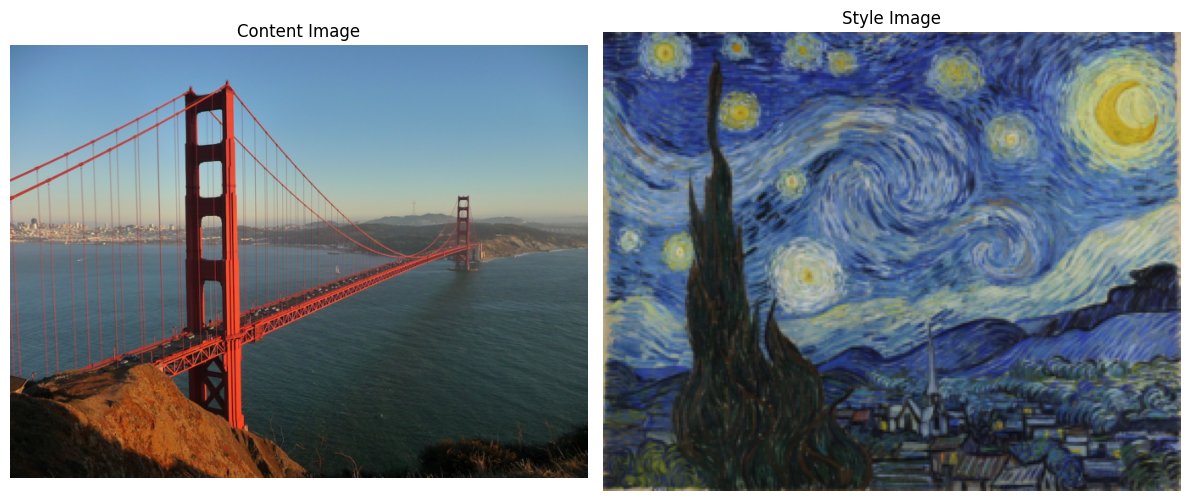

In [13]:
content_img = image_loader(CONTENT_IMG_PATH, IMG_SIZE, device)
style_img   = image_loader(STYLE_IMG_PATH, 224, device)

print(f"Content: {content_img.shape}  Style: {style_img.shape}")
_, _, H, W = content_img.shape

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(content_img[0].permute(1, 2, 0).cpu())
axes[0].set_title("Content Image")
axes[0].axis("off")
axes[1].imshow(style_img[0].permute(1, 2, 0).cpu())
axes[1].set_title("Style Image")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Stage 1: Brushstroke Optimization

Optimize N brushstrokes parameterized as quadratic Bezier curves. Each stroke has:
- **Location** $(x, y)$: center position on canvas
- **Bezier control points** $(s, c, e)$: start, control, end — relative to location
- **Color** $(r, g, b)$: RGB values in $[0, 1]$
- **Width** $w$: stored in log-space

Two separate Adam optimizers are used:
- **Geometry optimizer** (lr=0.1): location, curve points, width — driven by content + style + TV + curvature losses
- **Color optimizer** (lr=0.01): color — driven by style loss only

In [14]:
# Build VGG loss module for brushstroke stage
vgg_loss_bs = StyleTransferLosses(
    VGG_WEIGHTS, content_img, style_img,
    BS_CONTENT_LAYERS, BS_STYLE_LAYERS, scale_by_y=True,
)
vgg_loss_bs.to(device).eval()

# Initialize brushstroke renderer from content image (SLIC superpixels)
content_np = content_img[0].permute(1, 2, 0).cpu().numpy()
bs_renderer = BrushStrokeRenderer(
    H, W,
    num_strokes=NUM_STROKES,
    samples_per_curve=SAMPLES_PER_CURVE,
    strokes_per_pixel=BRUSHES_PER_PIXEL,
    canvas_color=CANVAS_COLOR,
    length_scale=LENGTH_SCALE,
    width_scale=WIDTH_SCALE,
    content_img=content_np,
)
bs_renderer.to(device)
print(f"Initialized {bs_renderer.location.shape[0]} brushstrokes on {H}x{W} canvas")

VGG19 weights loaded.
Initialized 6408 brushstrokes on 512x682 canvas


In [15]:
# Two optimizers: geometry at higher LR, color at lower LR
optimizer_geom = optim.Adam(
    [bs_renderer.location, bs_renderer.curve_s, bs_renderer.curve_e,
     bs_renderer.curve_c, bs_renderer.width],
    lr=BS_LR_GEOM,
)
optimizer_color = optim.Adam([bs_renderer.color], lr=BS_LR_COLOR)

# Loss tracking
bs_losses = {"content": [], "style": [], "tv": [], "curvature": [], "total": []}

print(f"Optimizing brushstrokes for {BS_STEPS} steps...")
for step in range(1, BS_STEPS + 1):
    optimizer_geom.zero_grad()
    optimizer_color.zero_grad()

    # Render canvas from current brushstroke parameters
    canvas = bs_renderer()                                          # [H, W, 3]
    canvas_img = canvas.unsqueeze(0).permute(0, 3, 1, 2).contiguous()  # [1, 3, H, W]

    # Compute VGG content & style losses
    content_loss, style_loss = vgg_loss_bs(canvas_img)
    content_loss = content_loss * BS_CONTENT_WEIGHT
    style_loss   = style_loss * BS_STYLE_WEIGHT

    # Brushstroke regularization losses
    tv_loss = BS_TV_WEIGHT * total_variation_loss(
        bs_renderer.location, bs_renderer.curve_s, bs_renderer.curve_e, K=10
    )
    curv_loss = BS_CURV_WEIGHT * curvature_loss(
        bs_renderer.curve_s, bs_renderer.curve_e, bs_renderer.curve_c
    )

    # Backward pass for geometry parameters (all losses)
    loss = content_loss + style_loss + tv_loss + curv_loss
    loss.backward(
        inputs=[bs_renderer.location, bs_renderer.curve_s, bs_renderer.curve_e,
                bs_renderer.curve_c, bs_renderer.width],
        retain_graph=True,
    )
    optimizer_geom.step()

    # Backward pass for color (style loss only)
    style_loss.backward(inputs=[bs_renderer.color])
    optimizer_color.step()

    # Track losses
    bs_losses["content"].append(content_loss.item())
    bs_losses["style"].append(style_loss.item())
    bs_losses["tv"].append(tv_loss.item())
    bs_losses["curvature"].append(curv_loss.item())
    bs_losses["total"].append(loss.item())

    if step % 10 == 0 or step == 1:
        print(
            f"  Step {step:4d} | content={content_loss.item():.4f} "
            f"style={style_loss.item():.4f} tv={tv_loss.item():.4f} "
            f"curv={curv_loss.item():.4f}"
        )

    # Save intermediate results
    if step % 25 == 0:
        save_image(canvas_img, os.path.join(OUTPUT_DIR, f"stroke_step_{step:04d}.png"))

print("Brushstroke optimization complete.")

Optimizing brushstrokes for 100 steps...
  Step    1 | content=3.0756 style=21.3600 tv=402.6914 curv=0.7193
  Step   10 | content=3.2871 style=8.7252 tv=250.9835 curv=0.3980
  Step   20 | content=3.5437 style=5.2435 tv=152.3965 curv=0.4435
  Step   30 | content=3.6031 style=3.8869 tv=95.5683 curv=0.4538
  Step   40 | content=3.6150 style=3.1369 tv=62.2725 curv=0.4435
  Step   50 | content=3.6596 style=2.6408 tv=42.3788 curv=0.4249
  Step   60 | content=3.6787 style=2.3282 tv=30.6656 curv=0.4037
  Step   70 | content=3.6637 style=2.1497 tv=23.5941 curv=0.3820
  Step   80 | content=3.6736 style=2.0008 tv=18.9417 curv=0.3616
  Step   90 | content=3.7106 style=1.8763 tv=15.7255 curv=0.3455
  Step  100 | content=3.7241 style=1.8215 tv=13.3372 curv=0.3373
Brushstroke optimization complete.


### Brushstroke Stage Results

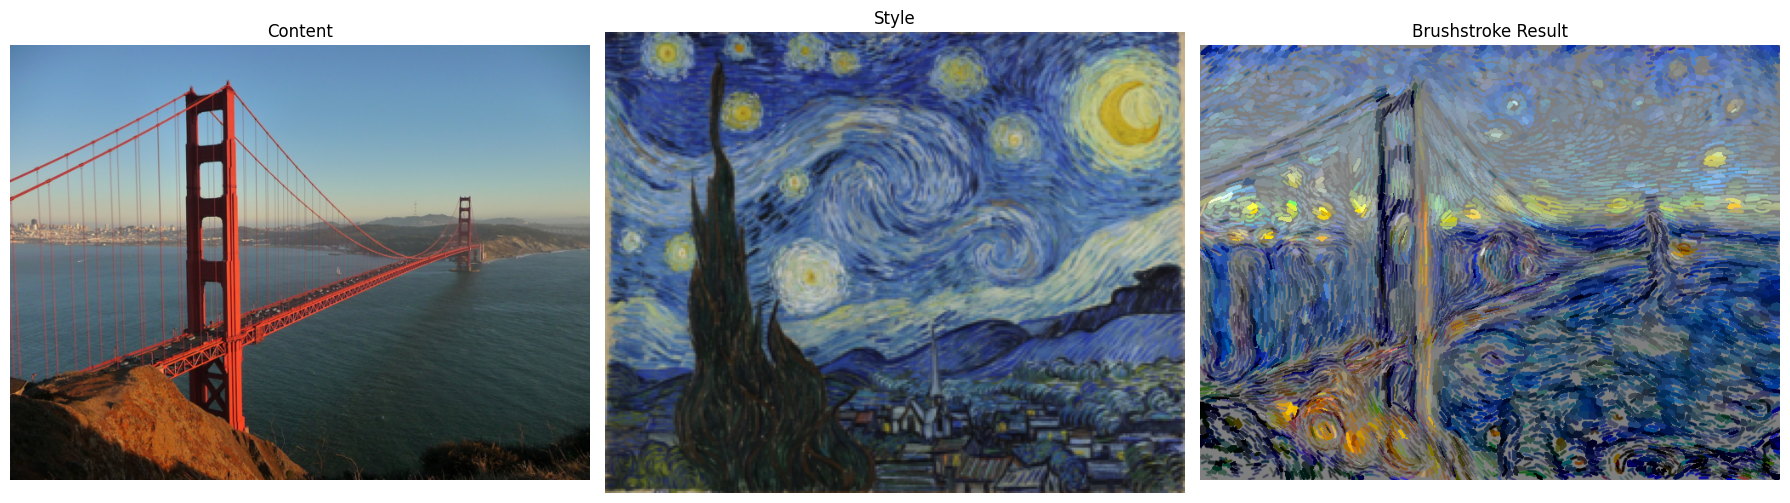

In [16]:
# Visualize brushstroke optimization result
with torch.no_grad():
    final_canvas_bs = bs_renderer()  # [H, W, 3]
    final_canvas_img = final_canvas_bs.unsqueeze(0).permute(0, 3, 1, 2)
    save_image(final_canvas_img, os.path.join(OUTPUT_DIR, "brushstroke_result.png"))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(content_img[0].permute(1, 2, 0).cpu())
axes[0].set_title("Content")
axes[0].axis("off")
axes[1].imshow(style_img[0].permute(1, 2, 0).cpu())
axes[1].set_title("Style")
axes[1].axis("off")
axes[2].imshow(final_canvas_bs.cpu().numpy().clip(0, 1))
axes[2].set_title("Brushstroke Result")
axes[2].axis("off")
plt.tight_layout()
plt.show()

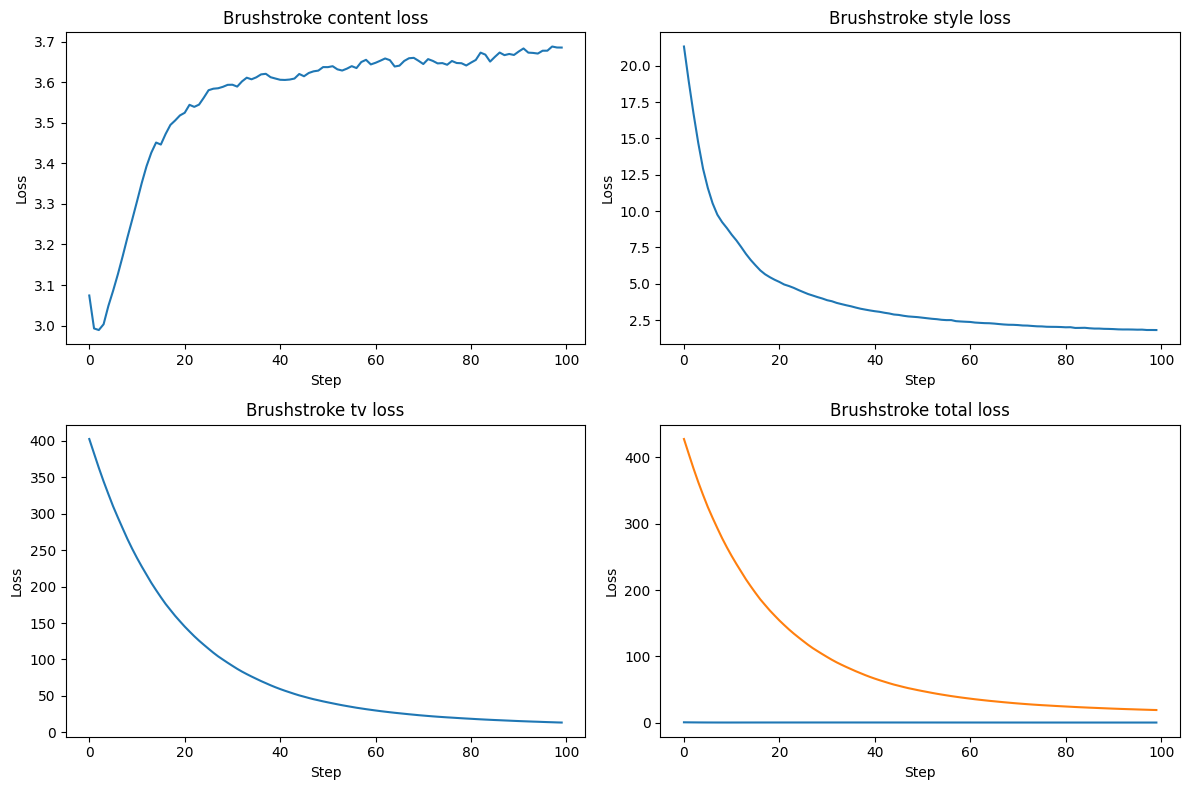

In [8]:
# Plot loss curves
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (name, vals) in zip(axes.flatten(), bs_losses.items()):
    if name == "total":
        continue
    ax.plot(vals)
    ax.set_title(f"Brushstroke {name} loss")
    ax.set_xlabel("Step")
    ax.set_ylabel("Loss")
axes[1, 1].plot(bs_losses["total"])
axes[1, 1].set_title("Brushstroke total loss")
axes[1, 1].set_xlabel("Step")
axes[1, 1].set_ylabel("Loss")
plt.tight_layout()
plt.show()